In [2]:
import torch
from torch import nn
# 많은 데이터들을 묶음
from torch.utils.data import DataLoader
from torchvision import datasets
# CPU로 옮김
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

In [3]:
training_data = datasets.FashionMNIST(
    root="data",
    train = True,
    download = True,
    transform=ToTensor(),
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100.0%


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [4]:
labels_map = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

In [36]:
training_data[0][0].shape
# 결과물에서 흑백은 1, 색깔은 3(RGB)

torch.Size([1, 28, 28])

In [6]:
len(training_data)

60000

In [7]:
test_data[0][0].shape

torch.Size([1, 28, 28])

In [8]:
len(test_data)

10000

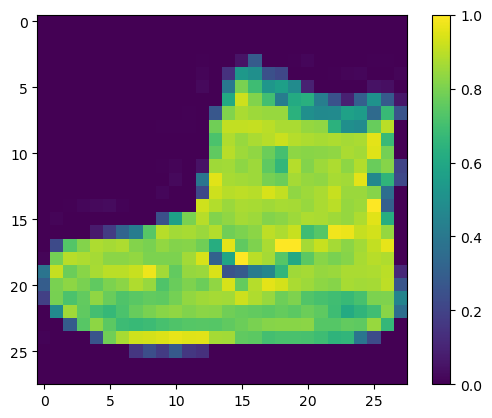

In [9]:
plt.figure()
#imshow는 2차원의 데이터 처리, squeeze로 3차원 처리
plt.imshow(training_data[0][0].squeeze())
plt.colorbar()
plt.grid(False)
plt.show()

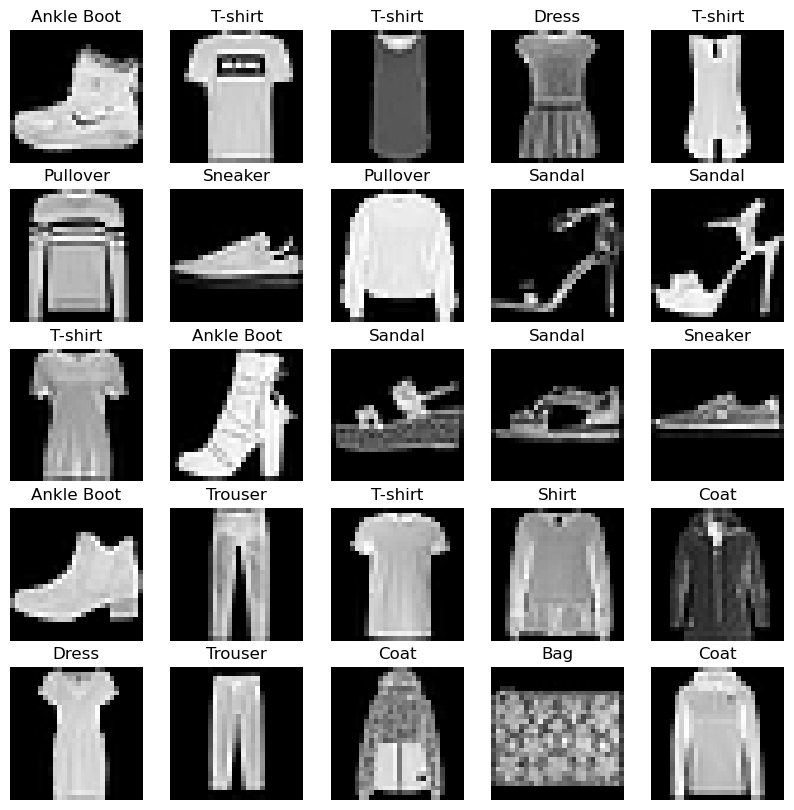

In [13]:
figure = plt.figure(figsize=(10,10))
cols, rows = 5, 5
for i in range(1,cols * rows + 1):
    sample_idx = i-1
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap ="gray")
plt.show()

In [37]:
#모델 한번 학습시킬 때 넣는 데이터 수
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [55]:
model = nn.Sequential(
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
    nn.Softmax()
)

In [59]:
# 학습에 사용할 CPU나 GPU 장치를 얻습니다.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# 모델을 정의합니다.
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model = NeuralNetwork().to(device)

Using cpu device


In [60]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

In [61]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # 예측 오류 계산
        pred = model(X)
        loss = loss_fn(pred, y)
        
        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        #100단위 출력
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [62]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            #모델을 통항 예측
            pred = model(X)
            #예측 결고 반영
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [51]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n--------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done")

Epoch 1
--------------------------
loss: 2.320024 [    0/60000]
loss: 2.307165 [ 6400/60000]
loss: 2.302425 [12800/60000]
loss: 2.294227 [19200/60000]
loss: 2.300132 [25600/60000]
loss: 2.309677 [32000/60000]
loss: 2.312754 [38400/60000]
loss: 2.318248 [44800/60000]
loss: 2.316696 [51200/60000]
loss: 2.305694 [57600/60000]
Test Error: 
 Accuracy: 9.2%, Avg loss: 2.305797 

Epoch 2
--------------------------
loss: 2.320024 [    0/60000]
loss: 2.307165 [ 6400/60000]
loss: 2.302425 [12800/60000]
loss: 2.294227 [19200/60000]
loss: 2.300132 [25600/60000]
loss: 2.309677 [32000/60000]
loss: 2.312754 [38400/60000]
loss: 2.318248 [44800/60000]
loss: 2.316696 [51200/60000]
loss: 2.305694 [57600/60000]
Test Error: 
 Accuracy: 9.2%, Avg loss: 2.305797 

Epoch 3
--------------------------
loss: 2.320024 [    0/60000]
loss: 2.307165 [ 6400/60000]
loss: 2.302425 [12800/60000]
loss: 2.294227 [19200/60000]
loss: 2.300132 [25600/60000]
loss: 2.309677 [32000/60000]
loss: 2.312754 [38400/60000]
loss: 2.31

In [64]:
with torch.no_grad():
    predictions = [model(X.to(device))[0] for X,y in test_data]

In [65]:
predictions[0]

tensor([-0.0080,  0.0293,  0.1045, -0.0107,  0.0250, -0.0130,  0.0009,  0.0558,
        -0.0283,  0.0767])

In [70]:
def plot_image(i, predictions_array, data):
    predictions_array, true_label, img = predictions_array[i].cpu().numpy(), data[i][1], data[i][0].squeeze()
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    plt.imshow(img, cmap=plt.cm.binary)
    
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    
    plt.xlabel("{} {:2.0f}% ({})".format(labels_map[predicted_label],
                                    100*np.max(predictions_array),
                                    labels_map[true_label]),
                                    color = color)
    
    def plot_value_array(i, predictions_array, data):
        predictions_Array, true_label = predictions_array[i].cpu().numpy(), data[i][1]
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        thisplot = plt.bar(range(10), predictions_array, color = "#777777")
        plt.ylim([0,1])
        preficted_label = np.argmax(predictions_array)
        
        thisplot[predicted_labbel].set_color('red')
        thisplot[true_labbel].set_color('blue')        

NameError: name 'plot_value_array' is not defined

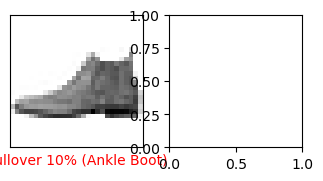

In [71]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, test_data)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, test_data)
plt.show()